# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


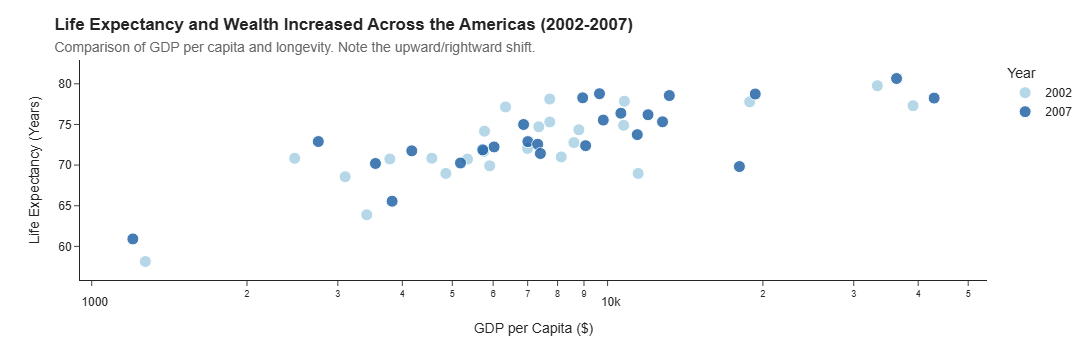

In [14]:
# Task 1 — Americas GDP vs Life Expectancy (2002-2007)
# ---------------------------------------------------

# 1. Filter data for Americas and the years 2002 and 2007
df_task1 = df.loc[(df['continent'] == 'Americas') & (df['year'].isin([2002, 2007]))].copy()

# 2. Convert year to string to ensure discrete legend markers
df_task1['year'] = df_task1['year'].astype(str)

# 3. Create the scatter plot
fig1 = px.scatter(
    df_task1, 
    x="gdpPercap", 
    y="lifeExp", 
    color="year", 
    # Light blue for 2002, Dark blue for 2007
    color_discrete_map={"2002": "#9ecae1", "2007": "#08519c"}, 
    hover_name="country",
    log_x=True,           # Rule 4: Log scale for GDP per capita
    template="simple_white"
)

# 4. Refine markers and layout styling
fig1.update_traces(
    marker=dict(size=12, opacity=0.75, line=dict(width=1, color='white'))
)

fig1.update_layout(
    title="<b>Life Expectancy and Wealth Increased Across the Americas (2002-2007)</b><br><span style='font-size:14px; color:#666666'>Comparison of GDP per capita and longevity. Note the upward/rightward shift.</span>",
    xaxis_title="GDP per Capita ($)",
    yaxis_title="Life Expectancy (Years)",
    legend_title="Year",
    font=dict(family="Arial")
)

fig1.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


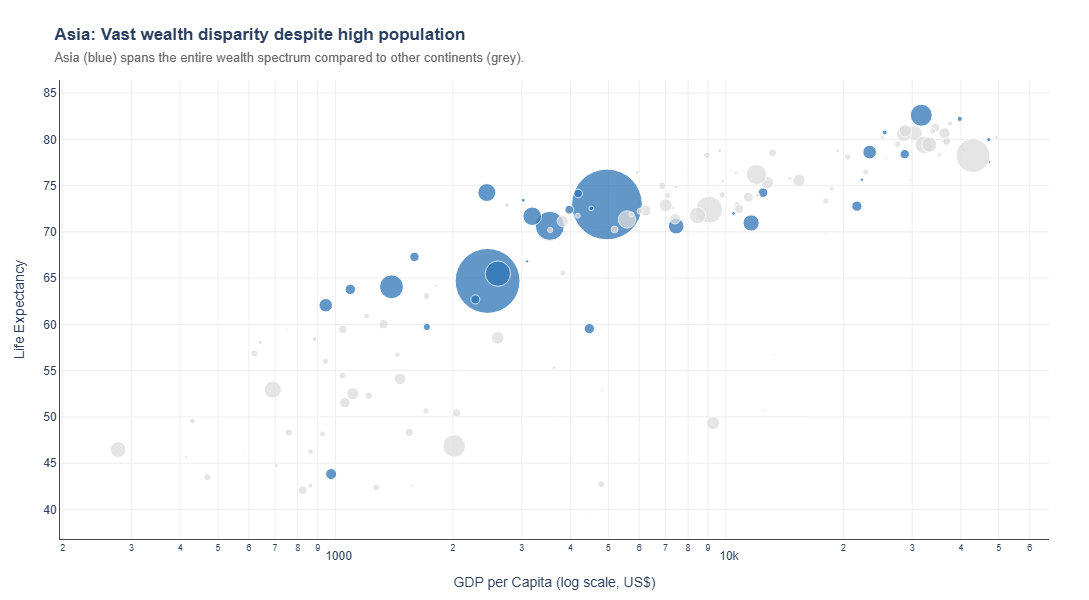

In [5]:
# Task 2
# 1. Prep data for 2007 only
df_2007 = df[df['year'] == 2007].copy()
df_2007['highlight'] = df_2007['continent'].apply(lambda x: 'Asia' if x == 'Asia' else 'Other')

# 2. Plotly Express base chart
fig2 = px.scatter(
    data_frame=df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',              # Bubble size based on population
    color='highlight',        # Highlighting Asia vs Other
    hover_name='country',
    title='<b>Asia: Vast wealth disparity despite high population</b><br><span style="font-size:13px; color:#666666">Asia (blue) spans the entire wealth spectrum compared to other continents (grey).</span>',
    labels={'gdpPercap': 'GDP per Capita (log scale, US$)', 'lifeExp': 'Life Expectancy'},
    color_discrete_map={'Asia': '#2E75B6', 'Other': '#DDDDDD'}, # Zysha's blue & light grey
    log_x=True,
    size_max=50,             # Rule 3: Set size_max
    height=600)

# 3. Customisation (Zysha's style)
fig2.update_traces(marker=dict(opacity=0.75, line=dict(width=1, color='White')))

fig2.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    showlegend=False,     
    margin=dict(l=60, r=40, t=80, b=40)
)

fig2.update_xaxes(gridcolor='#EEEEEE', showline=True, linecolor='#444444')
fig2.update_yaxes(gridcolor='#EEEEEE', showline=True, linecolor='#444444')

# 4. Add Annotation for the story
fig2.add_annotation(
    x=1000, y=45,
    text="Developing Asian nations<br>under 60 years life expectancy",
    showarrow=True, arrowhead=1, ax=50, ay=40,
    font=dict(color="#2E75B6")
)

fig2.show()
